# 08 · Agentic search and the end-to-end build: the AGENT layer and the FDE Lab

**FDE Academy · Accelerator track · Retrieval, RAG and Evals · Lab notebook 8 of 8**

You run the search loop on the worked question, watch it stop early with full confidence, fix that with a technique rather than a prompt, score the trace instead of the answer, measure when the loop earns its cost, then execute the FDE Lab brief end to end and write the decision record from the numbers.

| How to run | What it needs | Runs before | Runs after |
|---|---|---|---|
| Run All, top to bottom. Every cell executes offline in under a minute or two. | Python 3.10 or later with numpy, pandas, matplotlib and scikit-learn. `boto3` and `tiktoken` are optional and detected automatically. | Notebook 07. | The FDE Lab build, which this notebook is the brief for. |

Offline, the plan comes from the benchmark record and the sufficiency check is a stated heuristic; with a provider configured both are model calls. Everything else in the loop is real code and runs the same way in both modes.

## Where this sits on the pipeline

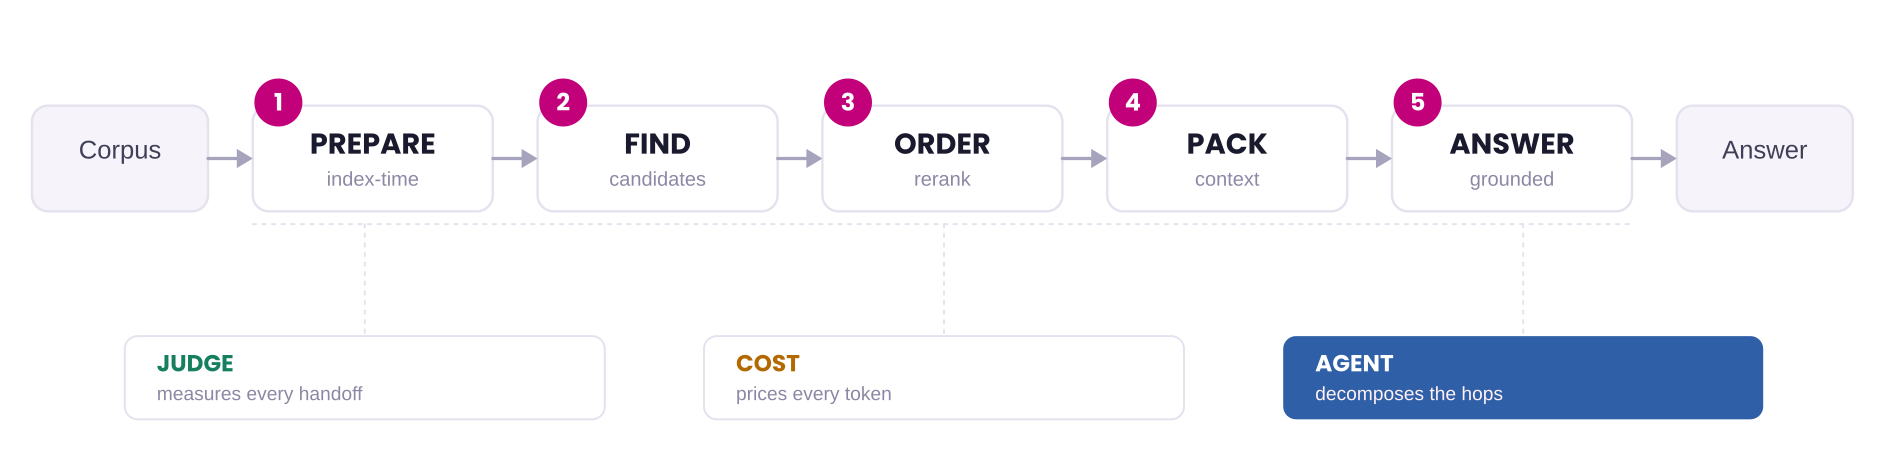

*The loop wraps FIND and JUDGE and multiplies their cost by the number of turns.*

## 1 · Decompose, and carry the bridge entity forward

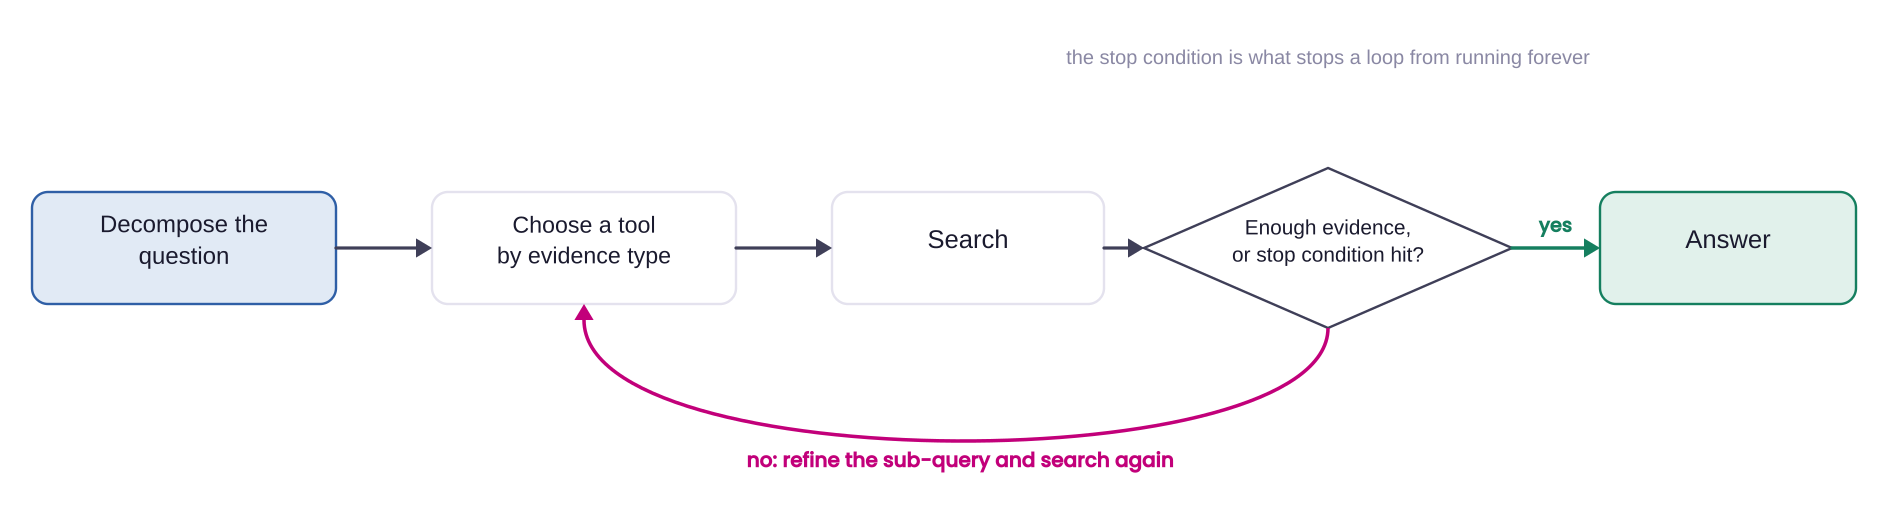

*From the session deck. Each box below becomes a function.*

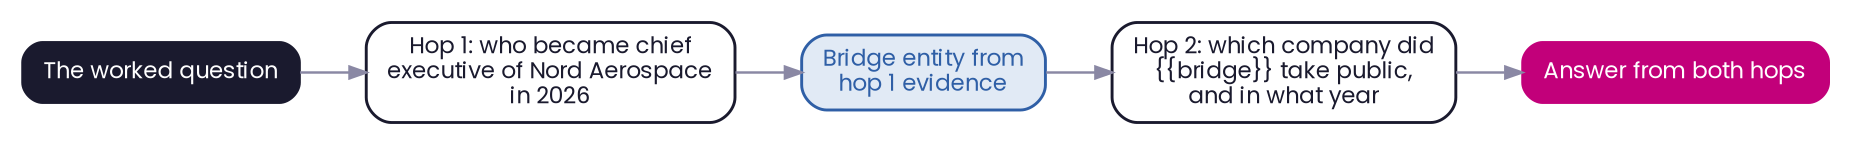

*The plan for the worked question. Offline it comes from the benchmark record, which is the plan a planner model would produce; the bridge is extracted by code from hop-one evidence.*

<details><summary>Mermaid source</summary>

```mermaid
flowchart LR
    q(["The worked question"])
    h1["Hop 1: who became chief<br/>executive of Nord Aerospace<br/>in 2026"]
    br["Bridge entity from<br/>hop 1 evidence"]
    h2["Hop 2: which company did<br/>{{bridge}} take public,<br/>and in what year"]
    ans(["Answer from both hops"])
    q --> h1
    h1 --> br
    br --> h2
    h2 --> ans
    class q start
    class br tool
    class ans endpt
    classDef dec fill:#FFF1F6,stroke:#C2007A,color:#C2007A
    classDef start fill:#1A1A2E,stroke:#1A1A2E,color:#fff
    classDef endpt fill:#C2007A,stroke:#C2007A,color:#fff
    classDef ok fill:#E1F1EB,stroke:#157F5F,color:#157F5F
    classDef fail fill:#FBE3E0,stroke:#C0392B,color:#C0392B
    classDef cost fill:#FBEBD2,stroke:#B26A00,color:#B26A00
    classDef tool fill:#E1EAF5,stroke:#2F5FA6,color:#2F5FA6
    classDef data fill:#F6F4FA,stroke:#8A88A4,color:#3F3F58
    classDef note fill:#F6F4FA,stroke:#E4E2EE,color:#3F3F58
```

</details>

In [1]:
# One-click setup. The notebook runs offline on numpy, pandas, matplotlib, scikit-learn and sqlite3.
# `ragkit` ships in the same folder as this notebook.
import sys, os
from pathlib import Path
for p in [Path.cwd(), *Path.cwd().parents]:
    if (p / "ragkit").is_dir():
        sys.path.insert(0, str(p)); break
import numpy as np, pandas as pd
import ragkit as rk
from ragkit import table, verdict_style, bars, lines, decision
rk.palette.style()
pd.set_option("display.width", 160)
print("ragkit", rk.__version__, "| provider:", rk.config()["provider"], "| tokenizer:", rk.TOKENIZER)

ragkit 0.1.0 | provider: mock | tokenizer: tiktoken cl100k_base


In [2]:
store, chunks, embedder, retriever, generator, questions = rk.bootstrap(chunker="structural")
texts = {c.chunk_id: c.text for c in chunks}; anchor = rk.ANCHOR; answerable = [q for q in questions if q.gold]
display(table(pd.DataFrame(anchor.plan), "The plan for the worked question"))
hop1 = anchor.plan[0]["text"]
top = [cid for cid, _ in retriever.hybrid(hop1, k=5)]
print("hop-one top chunks:", top)
for cid in top[:3]:
    print(f"  entities in {cid}: {rk.entities(texts[cid])}")
bridge = rk.carry_bridge([texts[c] for c in top[:3]], anchor.text, "person")
print("\nbridge carried into hop two:", bridge, "->", anchor.plan[1]["text"].replace("{bridge}", bridge))

text,depends_on,bridge_kind,tool
who became chief executive of Nord Aerospace in 2026,nan,,hybrid
"which company did {bridge} take public, and in what year",0.000,person,hybrid


hop-one top chunks: ['g2:0:7465c618', 'a1:0:63d9a4f8', 'a1:2:8d2011b6', 'a1:1:aca89706', 'l3:1:b31c0299']
  entities in g2:0:7465c618: {'person': ['Elena Ruiz'], 'company': ['Nord Aerospace', 'Nord Aerospace']}
  entities in a1:0:63d9a4f8: {'person': ['Elena Ruiz', 'Elena Ruiz'], 'company': ['Nord Aerospace', 'Nord Aerospace', 'Vega Dynamics']}
  entities in a1:2:8d2011b6: {'person': ['Elena Ruiz'], 'company': ['Nord Aerospace', 'Nord Aerospace']}

bridge carried into hop two: Elena Ruiz -> which company did Elena Ruiz take public, and in what year


| What goes wrong in a loop | The guard, as a config value in `AgentConfig` |
|---|---|
| Query drift: by turn four the agent searches for something adjacent to the question. | Every hop is written against the original question; the bridge is substituted into a fixed template, not into a rewritten question. |
| Evidence bloat: working evidence grows past the budget and the earliest, often best, results get dropped. | `working_cap` and `token_budget`; drops are recorded so evidence retention can be scored. |
| Tool thrash: the same query re-issued to three tools because none returned a confident result. | `repeat_detector` on the normalised query, and one refinement turn at most. |
| Premature confidence: the sufficiency check passes on partial evidence. | The check is a separate call with a strict schema; section 3 shows it failing anyway and what fixes it. |
| Cost blowout: nothing bounds the loop. | `max_turns`, `token_budget`, `deadline_ms`; a budget stop must produce a partial answer with a stated gap. |

## 2 · Select a tool per hop

Lexical for identifiers and exact names, dense for meaning, grep for repositories, SQL for aggregates, a live API for what the index cannot hold. The cell runs the selector over the sub-queries of the benchmark and scores it against the tool an expert would have picked.

In [3]:
rows = []
for q in questions:
    for h in q.plan:
        text = h["text"].replace("{bridge}", "Elena Ruiz" if q.qid == "q01" else "Brisk Automation" if q.qid == "q02" else "Amir Sadeghi")
        rows.append({"qid": q.qid, "sub-query": text[:60], "selected": rk.select_tool(text), "expert's pick": h["tool"], "match": rk.select_tool(text) == h["tool"]})
sel = pd.DataFrame(rows)
print(f"tool selection accuracy against the expert's pick: {sel['match'].mean():.2f}")
table(sel[~sel["match"]].assign(match="no"), "Where the selector and the expert disagree")

tool selection accuracy against the expert's pick: 0.95


qid,sub-query,selected,expert's pick,match
q10,chief financial officer of Nord Aerospace,hybrid,lexical,no


| Tool | Pick it when | Notebook that showed why |
|---|---|---|
| Lexical | The hop hinges on an exact name, code or identifier. | 01 and 04. |
| Dense | The hop is a paraphrase with no shared tokens. | 01. |
| Hybrid, fused | Both signals are present, which is the default for natural sub-questions. | 04. |
| Grep | The source is a repository or a log directory, not an index. | 04. |
| SQL or a live API | The answer is an aggregate or a value the index cannot hold. | Not modelled here; the interface is the same callable. |

## 3 · The loop on the worked question: stopping early with full confidence

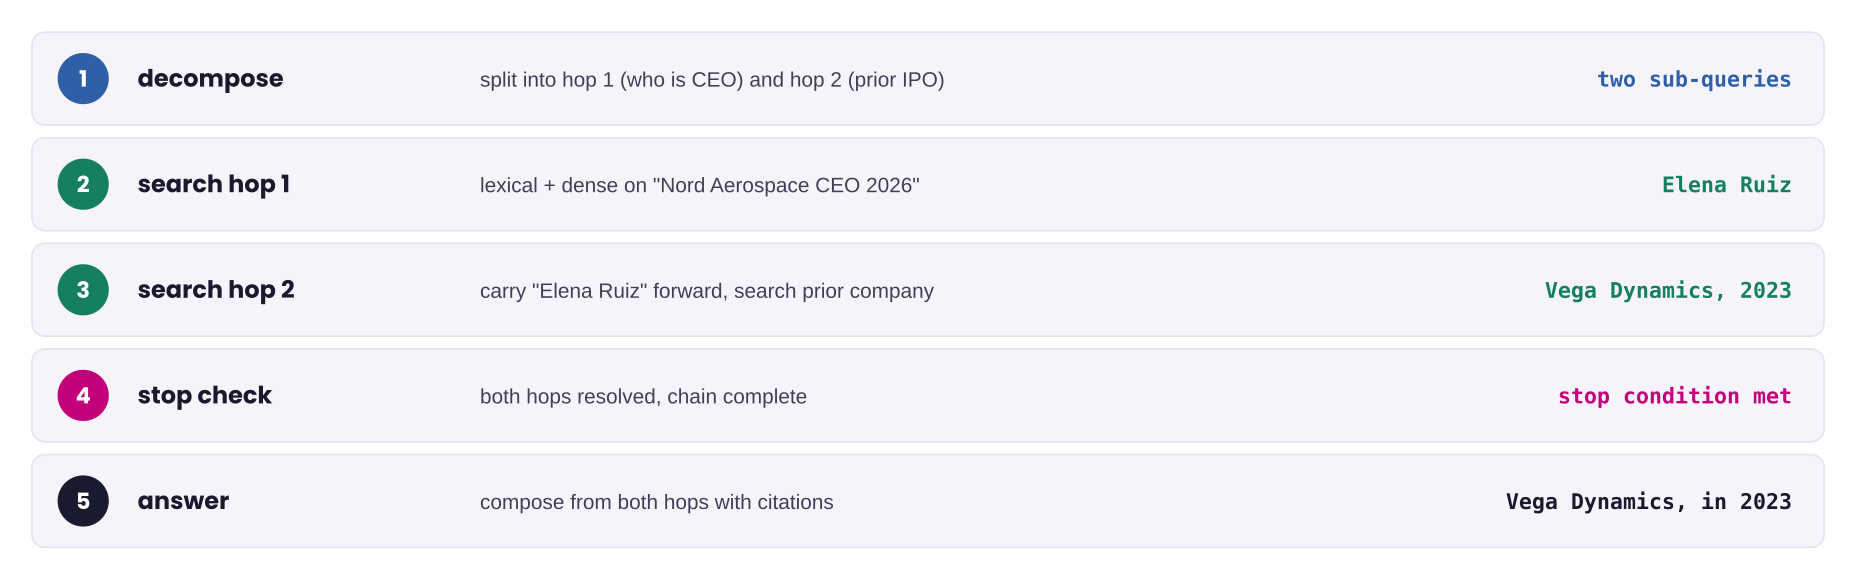

*From the session deck. The first run below does not get there, and the trace shows why.*

In [4]:
naive = rk.run_agent(anchor, retriever, texts, generator, rk.AgentConfig())
def show_trace(tr):
    rows = [{"turn": t["turn"], "tool": t["tool"], "query": t["query"][:58], "bridge": t["bridge"], "new evidence": ", ".join(t["new_evidence"][:3]) + ("..." if len(t["new_evidence"]) > 3 else ""), "working": t["working_size"], "tokens": t["evidence_tokens"]} for t in tr.turns]
    display(table(pd.DataFrame(rows), f"stop: {tr.stop_reason} | sufficiency check: {tr.sufficient} | simulated {tr.simulated_ms:.0f} ms"))
    print("answer:", tr.answer)
show_trace(naive)
gs = rk.gold_chunk_sets(anchor, chunks)
print("coverage of the gold spans in the packed context:", rk.coverage(gs, naive.packed), "| the check said sufficient:", naive.sufficient)

turn,tool,query,bridge,new evidence,working,tokens
1,hybrid,who became chief executive of Nord Aerospace in 2026,,"g2:0:7465c618, a1:0:63d9a4f8, a1:2:8d2011b6...",5,215
2,hybrid,"which company did Elena Ruiz take public, and in what year",Elena Ruiz,"b7:1:eb0b8d13, e2:1:a571f6be, r1:0:7e49a71b",8,353


answer: INSUFFICIENT EVIDENCE. Found part of the chain [a1:0:63d9a4f8] but could not confirm: b7: Shares of Vega Dynamics rose 28 percent ...
coverage of the gold spans in the packed context: 0.5 | the check said sufficient: True


The check passed because the hop-two chunk it found mentions Ruiz taking the company public and carries a year, 2020. The fact the question needs, the IPO date, sits in the sibling chunk that never entered the pool. This is premature confidence, and it is not fixed by a better prompt. It is fixed by reading the neighbours of a hit, which is parent-document retrieval, an established technique: retrieve by chunk, read by document.

In [5]:
fixed = rk.run_agent(anchor, retriever, texts, generator, rk.AgentConfig(expand_neighbours=True))
show_trace(fixed)
print("coverage now:", rk.coverage(gs, fixed.packed))

turn,tool,query,bridge,new evidence,working,tokens
1,hybrid,who became chief executive of Nord Aerospace in 2026,,"g2:0:7465c618, a1:0:63d9a4f8, a1:2:8d2011b6...",6,255
2,hybrid,"which company did Elena Ruiz take public, and in what year",Elena Ruiz,"b7:1:eb0b8d13, e2:1:a571f6be, r1:0:7e49a71b...",12,552


answer: Vega Dynamics, 2023 [a1:0:63d9a4f8] [b7:0:d9956799]
coverage now: 1.0


| Trace field | Why it is recorded |
|---|---|
| Per turn: query, tool, top ids, new evidence ids, working size, tokens, bridge | Q2 of the fault tree per hop, tool-selection scoring, and the query-drift check. |
| Working evidence in arrival order, never overwritten, plus the drops | Evidence retention: found it, then threw it away. |
| The sufficiency verdict and the stop reason | Stop-decision quality, and the audit line the UI usually shows. |
| Packed ids and the answer with citations | Faithfulness scoring and replay under a different model. |
| Simulated milliseconds and the generation count | The cost multiplier the next section measures. |

## 4 · Stop conditions are config, and a budget stop must still answer honestly

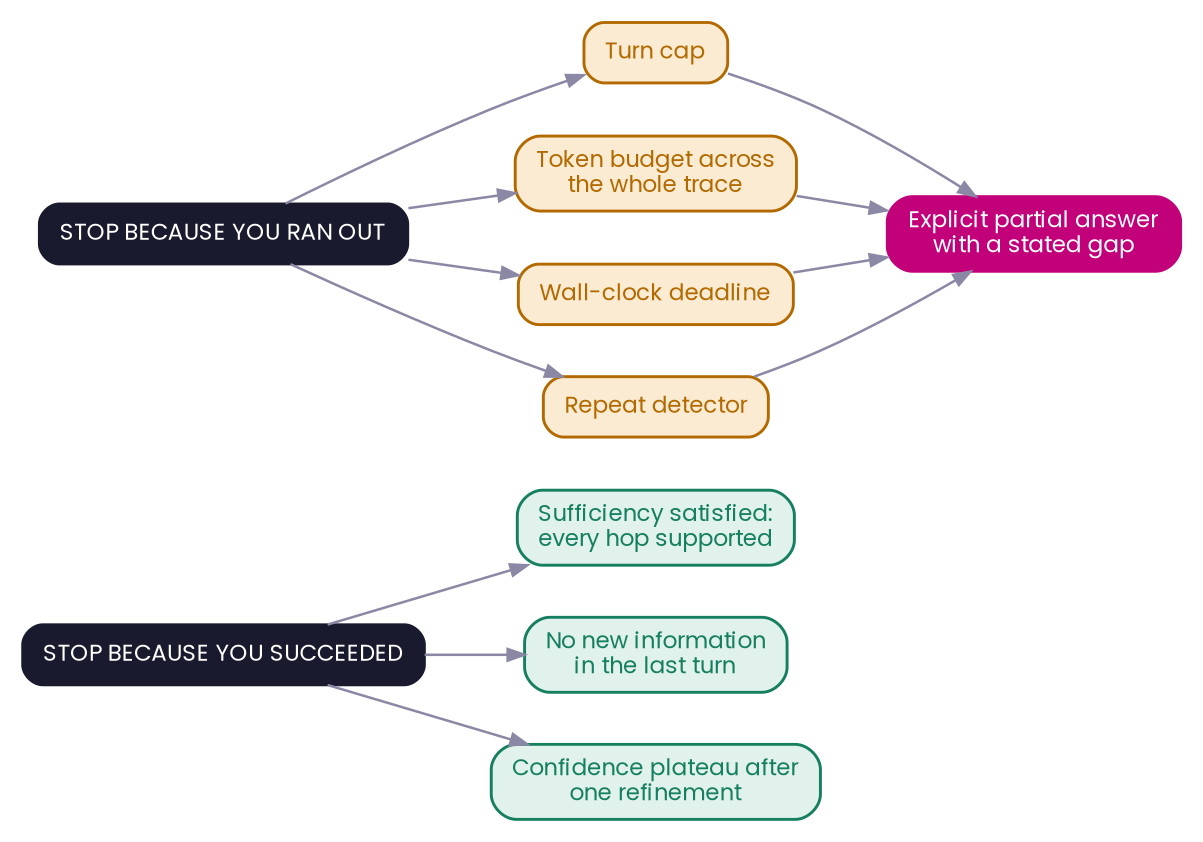

*From the advanced-track deck. Every box is a field of AgentConfig.*

<details><summary>Mermaid source</summary>

```mermaid
flowchart LR
    ok(["STOP BECAUSE YOU SUCCEEDED"])
    s1["Sufficiency satisfied:<br/>every hop supported"]
    s2["No new information<br/>in the last turn"]
    s3["Confidence plateau after<br/>one refinement"]
    out(["STOP BECAUSE YOU RAN OUT"])
    b1["Turn cap"]
    b2["Token budget across<br/>the whole trace"]
    b3["Wall-clock deadline"]
    b4["Repeat detector"]
    part(["Explicit partial answer<br/>with a stated gap"])
    ok --> s1
    ok --> s2
    ok --> s3
    out --> b1
    out --> b2
    out --> b3
    out --> b4
    b1 --> part
    b2 --> part
    b3 --> part
    b4 --> part
    class ok start
    class s1 ok
    class s2 ok
    class s3 ok
    class out start
    class b1 cost
    class b2 cost
    class b3 cost
    class b4 cost
    class part endpt
    classDef dec fill:#FFF1F6,stroke:#C2007A,color:#C2007A
    classDef start fill:#1A1A2E,stroke:#1A1A2E,color:#fff
    classDef endpt fill:#C2007A,stroke:#C2007A,color:#fff
    classDef ok fill:#E1F1EB,stroke:#157F5F,color:#157F5F
    classDef fail fill:#FBE3E0,stroke:#C0392B,color:#C0392B
    classDef cost fill:#FBEBD2,stroke:#B26A00,color:#B26A00
    classDef tool fill:#E1EAF5,stroke:#2F5FA6,color:#2F5FA6
    classDef data fill:#F6F4FA,stroke:#8A88A4,color:#3F3F58
    classDef note fill:#F6F4FA,stroke:#E4E2EE,color:#3F3F58
```

</details>

In [6]:
configs = {
    "default, neighbours": rk.AgentConfig(expand_neighbours=True),
    "turn cap 1": rk.AgentConfig(expand_neighbours=True, max_turns=1),
    "token budget 150": rk.AgentConfig(expand_neighbours=True, token_budget=150),
    "deadline 2,000 ms": rk.AgentConfig(expand_neighbours=True, deadline_ms=2000),
    "no refinement": rk.AgentConfig(expand_neighbours=True, refine_once=False),
}
rows = []
for name, cfg in configs.items():
    tr = rk.run_agent(anchor, retriever, texts, generator, cfg)
    rows.append({"config": name, "turns": len(tr.turns), "stop reason": tr.stop_reason, "simulated ms": round(tr.simulated_ms), "answer": tr.answer[:75] + ("..." if len(tr.answer) > 75 else "")})
table(pd.DataFrame(rows), "The worked question under five stop configurations")

config,turns,stop reason,simulated ms,answer
"default, neighbours",2,sufficiency satisfied,2502,"Vega Dynamics, 2023 [a1:0:63d9a4f8] [b7:0:d9956799]"
turn cap 1,1,turn cap,2151,INSUFFICIENT EVIDENCE. Found part of the chain [a1:0:63d9a4f8] but could no...
token budget 150,1,token budget,2151,INSUFFICIENT EVIDENCE. Found part of the chain [a1:0:63d9a4f8] but could no...
"deadline 2,000 ms",2,wall-clock deadline,2501,"Vega Dynamics, 2023 [a1:0:63d9a4f8] [b7:0:d9956799]"
no refinement,2,sufficiency satisfied,2501,"Vega Dynamics, 2023 [a1:0:63d9a4f8] [b7:0:d9956799]"


| If the loop stopped because | Then the answer must be | Because |
|---|---|---|
| Sufficiency was satisfied. | A full answer with a citation per fact. | That is the only stop that licenses a confident synthesis. |
| A budget ran out (turns, tokens, deadline). | An explicit partial answer with the gap named, as the table shows: found A, could not confirm B. | A confident synthesis of half the evidence is the worst outcome a loop can produce. |
| The same query came back, or nothing new arrived. | The same partial answer, and the stop reason in the trace. | Tool thrash and no-progress loops are cost with no information. |

Every one of these is a config value with a default. Write them down before you write the loop.

## 5 · Evaluate the trace, not just the answer

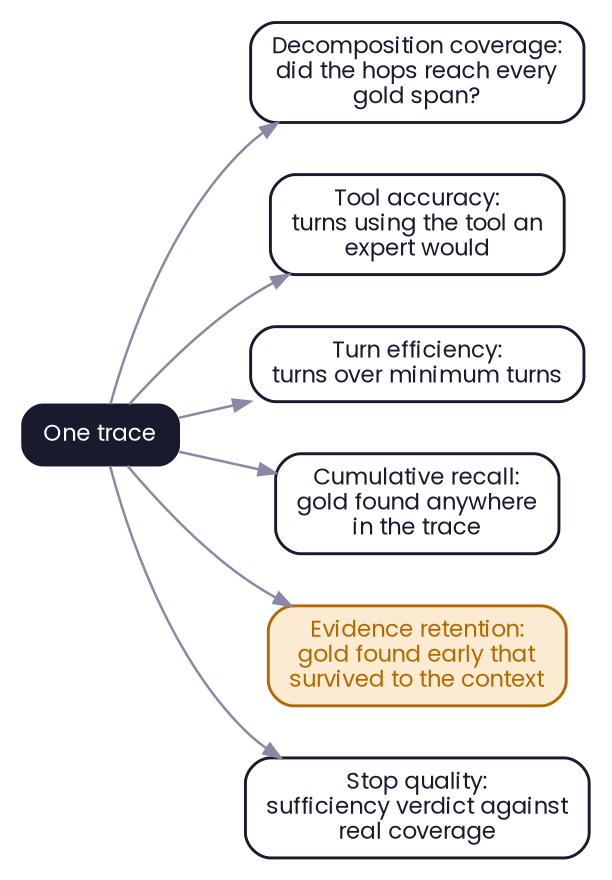

*From the advanced-track deck. Answer-only scoring cannot tell a lucky agent from a good one.*

<details><summary>Mermaid source</summary>

```mermaid
flowchart LR
    t(["One trace"])
    m1["Decomposition coverage:<br/>did the hops reach every<br/>gold span?"]
    m2["Tool accuracy:<br/>turns using the tool an<br/>expert would"]
    m3["Turn efficiency:<br/>turns over minimum turns"]
    m4["Cumulative recall:<br/>gold found anywhere<br/>in the trace"]
    m5["Evidence retention:<br/>gold found early that<br/>survived to the context"]
    m6["Stop quality:<br/>sufficiency verdict against<br/>real coverage"]
    t --> m1
    t --> m2
    t --> m3
    t --> m4
    t --> m5
    t --> m6
    class t start
    class m5 cost
    classDef dec fill:#FFF1F6,stroke:#C2007A,color:#C2007A
    classDef start fill:#1A1A2E,stroke:#1A1A2E,color:#fff
    classDef endpt fill:#C2007A,stroke:#C2007A,color:#fff
    classDef ok fill:#E1F1EB,stroke:#157F5F,color:#157F5F
    classDef fail fill:#FBE3E0,stroke:#C0392B,color:#C0392B
    classDef cost fill:#FBEBD2,stroke:#B26A00,color:#B26A00
    classDef tool fill:#E1EAF5,stroke:#2F5FA6,color:#2F5FA6
    classDef data fill:#F6F4FA,stroke:#8A88A4,color:#3F3F58
    classDef note fill:#F6F4FA,stroke:#E4E2EE,color:#3F3F58
```

</details>

In [7]:
def trace_table(cfg, label):
    rows = []
    for q in questions:
        tr = rk.run_agent(q, retriever, texts, generator, cfg); m = rk.trace_metrics(tr, q, chunks); m["correct"] = rk.correctness(q, tr.answer); rows.append(m)
    df = pd.DataFrame(rows); s = df.drop(columns=["qid", "stop"]).mean(numeric_only=True).round(2); s.name = label
    return df, s
naive_df, naive_s = trace_table(rk.AgentConfig(), "naive loop")
nb_df, nb_s = trace_table(rk.AgentConfig(expand_neighbours=True), "loop with neighbour expansion")
cap_df, cap_s = trace_table(rk.AgentConfig(expand_neighbours=True, working_cap=4), "neighbours, working cap 4")
display(table(pd.DataFrame([naive_s, nb_s, cap_s]).reset_index().rename(columns={"index": "configuration"}), "Trace metrics averaged over the benchmark; null questions have no gold so their recall columns are excluded from the mean"))
table(nb_df[["qid", "turns", "stop", "decomposition coverage", "cumulative recall", "evidence retention", "stop quality", "correct"]], "Per question, neighbour expansion")

configuration,turns,decomposition coverage,tool accuracy,turn efficiency,cumulative recall,evidence retention,stop quality,correct
naive loop,1.750,0.890,0.920,1.000,0.890,1.000,0.580,0.830
loop with neighbour expansion,1.750,0.890,0.920,1.000,1.000,1.000,0.750,1.000
"neighbours, working cap 4",2.000,0.890,0.830,1.120,1.000,0.780,0.670,0.670


qid,turns,stop,decomposition coverage,cumulative recall,evidence retention,stop quality,correct
q01,2,sufficiency satisfied,0.500,1.000,1.000,1.000,1.000
q02,2,sufficiency satisfied,1.000,1.000,1.000,1.000,1.000
q03,2,sufficiency satisfied,0.500,1.000,1.000,1.000,1.000
q04,2,sufficiency satisfied,1.000,1.000,1.000,1.000,1.000
q05,2,sufficiency satisfied,1.000,1.000,1.000,1.000,1.000
q06,2,sufficiency satisfied,1.000,1.000,1.000,1.000,1.000
q07,2,sufficiency satisfied,1.000,1.000,1.000,1.000,1.000
q08,2,sufficiency satisfied,1.000,1.000,1.000,1.000,1.000
q09,2,sufficiency satisfied,1.000,1.000,1.000,1.000,1.000
q10,1,sufficiency satisfied,nan,nan,nan,0.000,1.000


| Trace property | A bad score means | What you saw |
|---|---|---|
| Decomposition coverage | The plan was wrong; no amount of retrieval will rescue it. | 0.89: the sub-questions alone reached both spans for every comparison and temporal question, and for the two dependent questions they reached the right document but not the gold chunk, which neighbour expansion then supplied (cumulative recall 1.0). |
| Tool selection accuracy | Tool descriptions are ambiguous, or there are too many tools. | One disagreement with the expert's pick on a null question. |
| Turn efficiency | Cost is being burned on redundant search. | 1.0: each hop took one turn. |
| Cumulative evidence recall | The loop never reached the second hop. | The naive loop missed a second-hop span on two questions; neighbour expansion found them all. |
| Evidence retention | You found it and then threw it away, the worst and most invisible failure. | With a working cap of four, retention fell: gold found in turn one was evicted by turn two. |
| Stop-decision quality | Premature confidence, or loops that never terminate. | The heuristic check called the null questions answerable because a chunk about some other firm's CFO exists. A strict-schema model call is the production fix; the metric is what catches it either way. |

## 6 · When the loop earns its cost

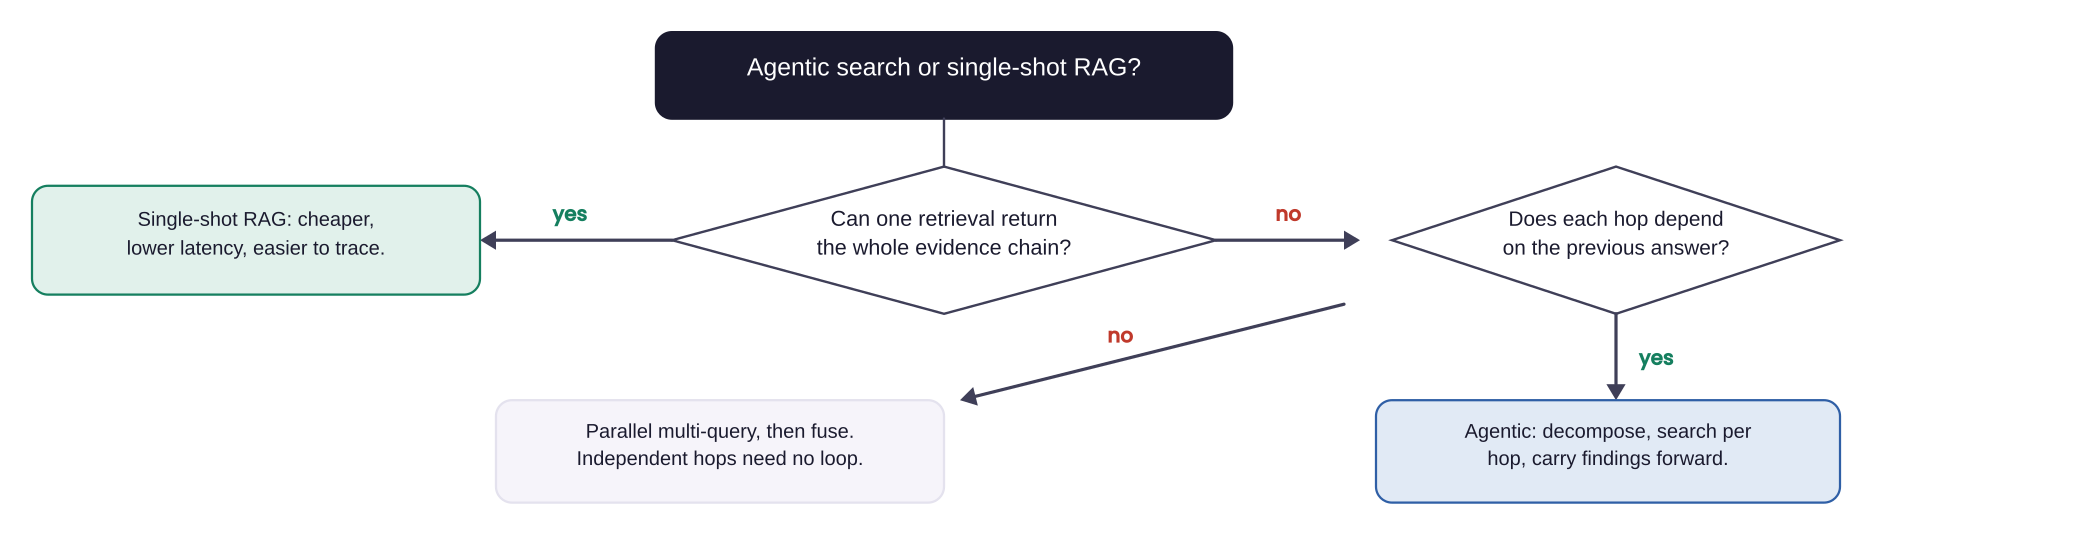

*From the session deck. The cell measures all three on the benchmark, then measures the escalation policy that runs single-shot by default.*

mode,full_chain@k,correct,evidence tokens,simulated ms,dollars per query
"single-shot, hybrid k=10",0.88900,0.91700,427,1900,0.00452
"parallel sub-queries, fused",0.88900,0.91700,338,2500,0.00426
agentic loop,1.00000,1.00000,377,2500,0.00437


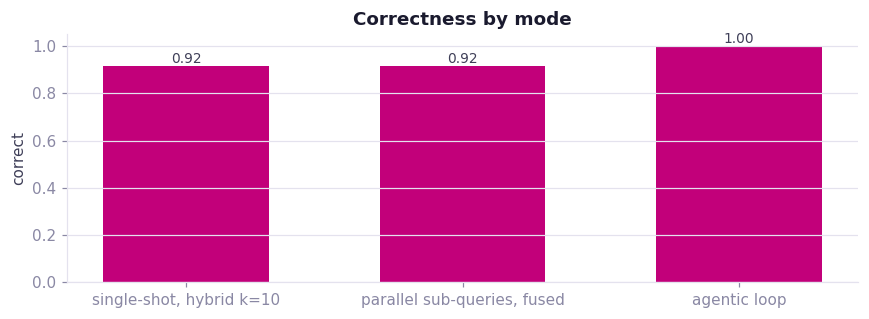

In [8]:
RATES = rk.Rates(); PREFIX_TOKENS = 3000; OUT_TOKENS = 150
def parallel_pool(q, r):
    seen, out = set(), []
    for h in (q.plan or [{"text": q.text}]):
        for cid, s in r.search(h["text"].replace("{bridge}", ""), k=5, mode="hybrid"):
            if cid not in seen: seen.add(cid); out.append((cid, s))
    return out
loop_cfg = rk.AgentConfig(expand_neighbours=True)
def loop_pool(q, r): return rk.decompose_pool(q, r, texts, loop_cfg, only_types=("inference", "comparison", "temporal", "null"))
K = 10
modes = {"single-shot, hybrid k=10": (rk.RunConfig("single", mode="hybrid", k=K), 1, 0),
         "parallel sub-queries, fused": (rk.RunConfig("parallel", mode="hybrid", k=K, decompose=parallel_pool), 1, 2),
         "agentic loop": (rk.RunConfig("loop", mode="hybrid", k=K, decompose=loop_pool), 1, 2)}
rows = []
for name, (cfg, gens, turns) in modes.items():
    df = rk.run_benchmark(cfg, retriever, generator, questions, chunks); s = rk.summarize(df)
    ms = 350 * max(1, turns) + (250 if turns else 0) + 1550 * gens
    dollars = np.mean([rk.query_cost(PREFIX_TOKENS, int(e), 30, OUT_TOKENS, RATES, cached=True)["total"] for e in df["evidence_tokens"]])
    rows.append({"mode": name, "full_chain@k": s["full_chain@k"], "correct": s["correct"], "evidence tokens": round(s["evidence_tokens"]), "simulated ms": ms, "dollars per query": round(dollars, 5)})
cmp = pd.DataFrame(rows)
display(table(cmp, "Three modes at k=10. Latency is measured retrieval plus the illustrative per-turn and generation figures from the latency budget", precision=5))
bars(list(cmp["mode"]), list(cmp["correct"]), "Correctness by mode", "correct", fmt="{:.2f}", figsize=(8, 3))

In [9]:
# the escalation policy: single-shot first, escalate to the loop only when the sufficiency check on the single-shot context fails
escalated, rows = 0, []
for q in questions:
    pool = retriever.hybrid(q.text, k=50); packed = rk.pack(pool, texts, evidence_cap=6000, k=K)
    hops = [h["text"].replace("{bridge}", "") for h in (q.plan or [{"text": q.text}])]
    ok, _ = rk.sufficiency_check(hops, packed.chunk_ids, texts)
    if ok:
        ans = generator.answer(q, packed.chunk_ids, texts).text; ms = 350 + 250 + 1550; tokens = packed.tokens
    else:
        escalated += 1; tr = rk.run_agent(q, retriever, texts, generator, loop_cfg); ans = tr.answer; ms = 350 + 250 + tr.simulated_ms; tokens = tr.evidence_tokens
    rows.append({"qid": q.qid, "type": q.qtype, "escalated": not ok, "correct": rk.correctness(q, ans), "ms": round(ms), "tokens": tokens})
esc = pd.DataFrame(rows)
print(f"escalated {escalated} of {len(questions)} questions; correctness {esc['correct'].mean():.3f}; mean simulated latency {esc['ms'].mean():.0f} ms; mean evidence tokens {esc['tokens'].mean():.0f}")
table(esc, "Escalation per question")

escalated 0 of 12 questions; correctness 0.917; mean simulated latency 2150 ms; mean evidence tokens 427


qid,type,escalated,correct,ms,tokens
q01,inference,False,0.000,2150,416
q02,inference,False,1.000,2150,437
q03,inference,False,1.000,2150,464
q04,comparison,False,1.000,2150,434
q05,comparison,False,1.000,2150,391
q06,comparison,False,1.000,2150,401
q07,temporal,False,1.000,2150,457
q08,temporal,False,1.000,2150,420
q09,temporal,False,1.000,2150,457
q10,null,False,1.000,2150,432


| Signal | Single-shot RAG | Agentic search | What this benchmark measured |
|---|---|---|---|
| Question shape | Answerable from evidence one query can surface. | Later hops depend on what earlier hops returned. | The two dependent inference questions are the only ones single-shot could not answer at k=10. |
| Latency | One retrieval and one generation, predictable. | Turns times the pre-generation cost, plus a sufficiency call; high variance. | About 2,500 ms against about 1,900 ms in the simulation. |
| Cost per query | One generation. | More calls, and on hard questions more evidence; the tail is what hurts. | Fewer evidence tokens in the loop at the same k here, since each hop's pool is small and k caps the pack; the cost is in the extra retrieval turn and the sufficiency call. |
| Failure mode | Missing evidence, one bad answer. | Compounding drift, premature confidence. | Stop quality caught the check passing on null questions. |
| What you evaluate | One retrieval and one answer. | The whole trace. | Section 5. |

The useful middle is the escalation policy: single-shot by default, and the loop only when the sufficiency check on the first pass fails. Most traffic pays single-shot cost; the hard questions get the budget they need. The cell above shows its dependency: the heuristic check passed the worked question's single-shot context, so nothing escalated and the question stayed wrong. An escalation policy is only as good as the sufficiency check that triggers it, and stop quality in section 5 is the metric that tells you whether the check can be trusted.

In [10]:
LOOP_TREE = [
    {"q": "Do later hops depend on what earlier hops return?", "test": lambda f: f["dependent"], "yes": None, "no": "single-shot or parallel sub-queries; the loop buys nothing", "show": lambda f: f"dependent={f['dependent']}"},
    {"q": "Is there latency budget for at least two retrieval turns plus a sufficiency call?", "test": lambda f: f["latency_budget_ms"] >= 2 * 350 + 250 + 1550, "yes": None, "no": "single-shot with a wide k and a partial-answer contract", "show": lambda f: f"budget={f['latency_budget_ms']} ms"},
    {"q": "Does the cost ceiling absorb three to twenty times a single generation on hard questions?", "test": lambda f: f["cost_ceiling"] >= 3 * f["single_cost"], "yes": "escalate to the loop when the single-shot sufficiency check fails", "no": "single-shot, and route hard questions to a human or a queue", "show": lambda f: f"ceiling={f['cost_ceiling']}, single={f['single_cost']:.4f}"},
]
single_cost = float(cmp.loc[0, "dollars per query"])
display(table(decision(LOOP_TREE, {"dependent": True, "latency_budget_ms": 4000, "cost_ceiling": 0.03, "single_cost": single_cost}), "The worked question under the FDE Lab constraints"))
table(decision(LOOP_TREE, {"dependent": False, "latency_budget_ms": 1500, "cost_ceiling": 0.005, "single_cost": single_cost}), "A comparison question in a tight interactive product")

question,measured,answer
Do later hops depend on what earlier hops return?,dependent=True,yes
Is there latency budget for at least two retrieval turns plus a sufficiency call?,budget=4000 ms,yes
Does the cost ceiling absorb three to twenty times a single generation on hard questions?,"ceiling=0.03, single=0.0045",yes
Outcome,,escalate to the loop when the single-shot sufficiency check fails


question,measured,answer
Do later hops depend on what earlier hops return?,dependent=False,no
Outcome,,single-shot or parallel sub-queries; the loop buys nothing


## 7 · The whole system on one page, and the provider swap

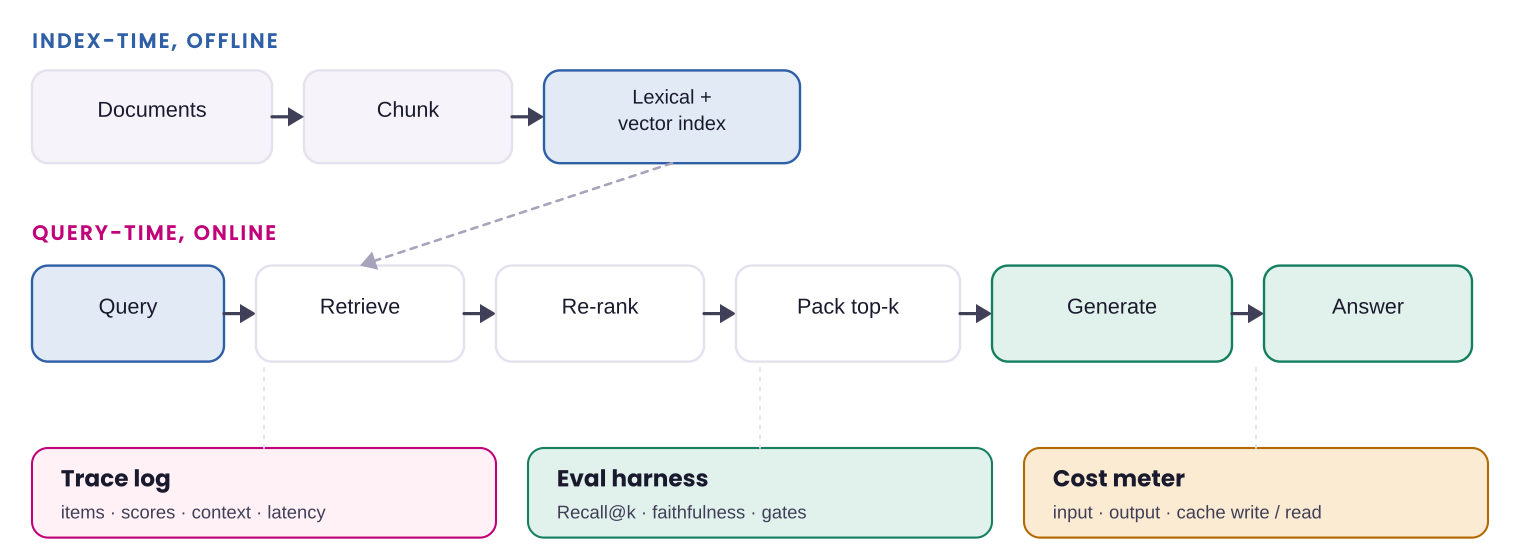

*The whiteboard to draw from memory. Everything above the query path is a batch job with a deploy step; everything on the query path has a p95; the control plane lets you change either without guessing.*

With `RAGKIT_PROVIDER=bedrock` and `RAGKIT_BEDROCK_KB_ID` set, `rk.get_kb()` returns a Bedrock Knowledge Base as a retriever with the same `search(query, k)` shape, so the loop above runs against it unchanged. Verified 2026-08-31: `bedrock-agent-runtime.retrieve` with `knowledgeBaseId`, `retrievalQuery` and a `vectorSearchConfiguration` carrying `numberOfResults` and an optional metadata `filter`.

In [11]:
kb = rk.get_kb()
if kb is None:
    print("provider is mock, or no knowledge base id is set. To run the loop against Bedrock:")
    print("  RAGKIT_PROVIDER=bedrock AWS_REGION=<region> RAGKIT_BEDROCK_KB_ID=<kb id>, then rerun this notebook.")
    print("  rk.get_llm() then returns a Converse-API model, rk.get_embedder() Titan V2, and rk.make_reranker('bedrock', ...) the rerank endpoint.")
else:
    hits = kb.search(anchor.text, k=5)
    display(table(pd.DataFrame([{"id": cid, "score": round(s, 3), "text": kb.text(cid)[:90]} for cid, s in hits]), "Bedrock Knowledge Base results for the worked question"))

provider is mock, or no knowledge base id is set. To run the loop against Bedrock:
  RAGKIT_PROVIDER=bedrock AWS_REGION=<region> RAGKIT_BEDROCK_KB_ID=<kb id>, then rerun this notebook.
  rk.get_llm() then returns a Converse-API model, rk.get_embedder() Titan V2, and rk.make_reranker('bedrock', ...) the rerank endpoint.


## 8 · The FDE Lab build brief, executed

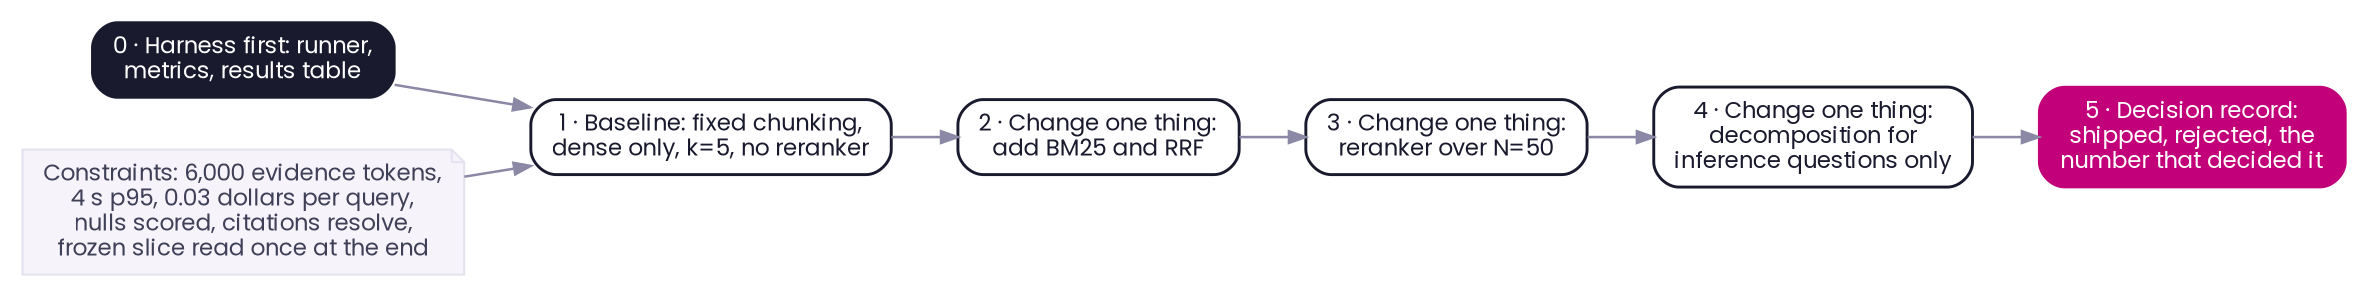

*The brief from the advanced-track deck. Each step below re-runs the same harness and records the delta and the cost delta.*

<details><summary>Mermaid source</summary>

```mermaid
flowchart LR
    h(["0 · Harness first: runner,<br/>metrics, results table"])
    b["1 · Baseline: fixed chunking,<br/>dense only, k=5, no reranker"]
    s2["2 · Change one thing:<br/>add BM25 and RRF"]
    s3["3 · Change one thing:<br/>reranker over N=50"]
    s4["4 · Change one thing:<br/>decomposition for<br/>inference questions only"]
    d(["5 · Decision record:<br/>shipped, rejected, the<br/>number that decided it"])
    c["Constraints: 6,000 evidence tokens,<br/>4 s p95, 0.03 dollars per query,<br/>nulls scored, citations resolve,<br/>frozen slice read once at the end"]
    h --> b
    b --> s2
    s2 --> s3
    s3 --> s4
    s4 --> d
    c --> b
    class h start
    class d endpt
    class c note
    classDef dec fill:#FFF1F6,stroke:#C2007A,color:#C2007A
    classDef start fill:#1A1A2E,stroke:#1A1A2E,color:#fff
    classDef endpt fill:#C2007A,stroke:#C2007A,color:#fff
    classDef ok fill:#E1F1EB,stroke:#157F5F,color:#157F5F
    classDef fail fill:#FBE3E0,stroke:#C0392B,color:#C0392B
    classDef cost fill:#FBEBD2,stroke:#B26A00,color:#B26A00
    classDef tool fill:#E1EAF5,stroke:#2F5FA6,color:#2F5FA6
    classDef data fill:#F6F4FA,stroke:#8A88A4,color:#3F3F58
    classDef note fill:#F6F4FA,stroke:#E4E2EE,color:#3F3F58
```

</details>

| Constraint | Value | Why it is there |
|---|---|---|
| Evidence token cap | 6,000 | You cannot buy recall by packing more. |
| p95 latency ceiling | 4 seconds end to end | Retrieval is nearly free; generation and turns are not. |
| Cost ceiling | 0.03 dollars per answered query, measured | Measured from tokens at the stated rates, not estimated. |
| Null questions | Ten injected in the brief, three here; abstention is scored | Answering them is a failure. |
| Citations | Every answer carries source ids that resolve to a chunk in the trace | Traceability is a rubric dimension. |
| Frozen slice | 15 percent held out; looked at once, at the end | The only number tuning cannot have touched. |

In [12]:
# 0 · harness first: the runner and metrics already exist (rk.run_benchmark, rk.summarize); this cell adds the constraint checks and the cost and latency lines
lab_store, lab_chunks, lab_emb, lab_ret, lab_gen, lab_q = rk.bootstrap(chunker="fixed_40")     # fixed chunking, as the brief specifies
lab_texts = {c.chunk_id: c.text for c in lab_chunks}
tuning = [q for q in lab_q if not q.frozen]; frozen = [q for q in lab_q if q.frozen]
CAP, P95_MS, COST_CEIL = 6000, 4000, 0.03
def latency_ms(cfg, df, turns_for_inference=0):
    t = rk.Timer(); per_q = []
    for q in lab_q:
        with t.stage(q.qid):
            pool = lab_ret.search(q.text, k=cfg.n_pool, mode=cfg.mode)
            if cfg.reranker: pool = cfg.reranker(q.text, pool)
            rk.pack(pool, lab_texts, evidence_cap=cfg.evidence_cap, k=cfg.k)
        extra = (350 * turns_for_inference + 250) if (turns_for_inference and q.qtype == "inference") else 0
        per_q.append(t.ms[q.qid] + 350 + 1550 + extra)
    return float(np.percentile(per_q, 95))
def run_step(name, cfg, turns_for_inference=0):
    df = rk.run_benchmark(cfg, lab_ret, lab_gen, tuning, lab_chunks, lab_store); s = rk.summarize(df)
    cost = float(np.mean([rk.query_cost(3000, int(e), 30, 150, RATES, cached=True)["total"] for e in df["evidence_tokens"]]))
    cites_ok = all(all(c in lab_texts for c in rk.citations_in(a)) for a in df["answer"])
    return {"step": name, "full_chain@5": s["full_chain@k"], "recall@pool": s["recall@pool"], "correct": s["correct"], "null_abstained": s["null_abstained"],
            "evidence tokens (max)": int(df["evidence_tokens"].max()), "p95 ms": round(latency_ms(cfg, df, turns_for_inference)), "dollars per query": round(cost, 5), "citations resolve": cites_ok}
steps = []
rr = rk.make_reranker("maxsim", lab_ret, lab_texts, top=50)
lab_loop = rk.AgentConfig(expand_neighbours=True, token_budget=CAP)
decomp = lambda q, r: rk.decompose_pool(q, r, lab_texts, lab_loop)
chain = [("1 · baseline: fixed_40, dense, k=5", dict(mode="dense"), 0),
         ("2 · + BM25 and RRF (hybrid)", dict(mode="hybrid"), 0),
         ("3 · + reranker over N=50", dict(mode="hybrid", reranker=rr), 0),
         ("4 · + decomposition, inference type only", dict(mode="hybrid", reranker=rr, decompose=decomp), 2)]
for name, kw, turns in chain:
    steps.append(run_step(name, rk.RunConfig(name[:1], n_pool=50, k=5, evidence_cap=CAP, **kw), turns))
lab = pd.DataFrame(steps)
lab["delta full_chain@5"] = lab["full_chain@5"].diff().round(3); lab["delta dollars"] = lab["dollars per query"].diff().round(5)
lab["within constraints"] = (lab["evidence tokens (max)"] <= CAP) & (lab["p95 ms"] <= P95_MS) & (lab["dollars per query"] <= COST_CEIL) & (lab["null_abstained"] >= 1.0) & lab["citations resolve"]
# the stack is kept up to the best cumulative step that passed its constraints; ties go to the cheaper step
ok = lab[lab["within constraints"]]
best = int(ok.sort_values(["full_chain@5", "dollars per query"], ascending=[False, True]).index[0])
lab["verdict"] = ["baseline" if i == 0 else ("shipped" if i <= best and (lab.loc[i, "delta full_chain@5"] > 0) else ("carried, zero delta" if i <= best else "rejected")) for i in range(len(lab))]
display(table(lab.drop(columns=["within constraints"]), "The chain, cumulative. Each step adds one change to the previous one, as the brief prescribes.", precision=5))

step,full_chain@5,recall@pool,correct,null_abstained,evidence tokens (max),p95 ms,dollars per query,citations resolve,delta full_chain@5,delta dollars,verdict
"1 · baseline: fixed_40, dense, k=5",0.71400,1.00000,0.77800,1.00000,265,1901,0.00390,True,nan,nan,baseline
2 · + BM25 and RRF (hybrid),0.71400,1.00000,0.77800,1.00000,265,1901,0.00389,True,0.00000,-0.00001,"carried, zero delta"
3 · + reranker over N=50,0.85700,1.00000,0.88900,1.00000,266,1903,0.00397,True,0.14300,0.00008,shipped
"4 · + decomposition, inference type only",0.85700,0.85700,0.88900,1.00000,266,2853,0.00397,True,0.00000,0.00000,rejected


| Step | What the rule says | Why |
|---|---|---|
| 1, baseline | Record every number before changing anything. | Without it no later delta means anything. |
| 2, hybrid | Write the delta and the cost delta even when one of them is zero; a zero-delta step that later steps build on is carried, not shipped. | Change one thing, and be honest about what it bought. |
| 3, reranker | Judge it on the full-chain delta at k, inside the constraints; the result differs by chunking, as notebook 04 showed on structural chunks. | A step that does not move the number is a finding, not a failure of the lab. |
| 4, decomposition | Applied to the inference type only, so latency rises on those questions alone; judged on the delta on top of the stack it lands on. | Spend the loop where the question shape demands it. |
| The stack that ships | The steps up to the best cumulative number that passed its constraints, ties broken by cost. | That is what a cumulative build is. |

In [13]:
# the frozen slice, looked at once, at the end, on the shipped configuration
shipped_kw = chain[best][1]
shipped = rk.RunConfig("shipped", n_pool=50, k=5, evidence_cap=CAP, **shipped_kw)
baseline = rk.RunConfig("base", mode="dense", n_pool=50, k=5, evidence_cap=CAP)
fz = pd.DataFrame([rk.summarize(rk.run_benchmark(baseline, lab_ret, lab_gen, frozen, lab_chunks), "baseline"), rk.summarize(rk.run_benchmark(shipped, lab_ret, lab_gen, frozen, lab_chunks), "shipped")]).reset_index().rename(columns={"index": "config"})
display(table(fz[["config", "full_chain@k", "correct", "null_abstained", "evidence_tokens"]], "The frozen slice (three questions), read once"))

# 5 · the decision record, generated from the numbers above
import hashlib, datetime as dt
version = hashlib.sha1("".join(d.body for d in lab_store.docs()).encode()).hexdigest()[:10]
def line(i):
    r = lab.iloc[i]; return f"{r['step']}: full-chain recall at 5 moved {r['delta full_chain@5']:+.3f} for {r['delta dollars']:+.5f} dollars per query and p95 {int(r['p95 ms'])} ms"
shipped_lines = [line(i) for i in range(1, len(lab)) if lab.loc[i, "verdict"] == "shipped"]
carried_lines = [line(i) for i in range(1, len(lab)) if lab.loc[i, "verdict"] == "carried, zero delta"]
rejected_lines = [line(i) for i in range(1, len(lab)) if lab.loc[i, "verdict"] == "rejected"]
fin = lab.iloc[best]
record = f"""
# Decision record: FDE Lab build, corpus {version}, {dt.date.today().isoformat()}

**Shipped.** {"; ".join(shipped_lines) if shipped_lines else "nothing beyond the baseline moved the number"}.

**Carried at zero delta**, because a later shipped step builds on it: {"; ".join(carried_lines) if carried_lines else "none"}.

**Rejected.** {"; ".join(rejected_lines) if rejected_lines else "none"}.

**The number that decided it.** Full-chain recall at k=5 on the tuning slice across the chain: {", ".join(f"{v:.3f}" for v in lab["full_chain@5"])}. The stack ships up to step {best + 1}. Frozen slice, read once: {fz.loc[0, "full_chain@k"]:.3f} baseline against {fz.loc[1, "full_chain@k"]:.3f} shipped.

**Constraints, measured on the shipped stack.** Evidence cap 6,000 against a maximum of {int(fin["evidence tokens (max)"])} tokens. p95 {int(fin["p95 ms"])} ms against a 4,000 ms ceiling (retrieval measured, generation and turn costs illustrative). Cost {fin["dollars per query"]:.5f} dollars per query against 0.03 at the stated rates. Null abstention {fin["null_abstained"]:.2f}. Citations resolve: {fin["citations resolve"]}.

**Revisit when.** A trained or hosted reranker is available (rerun step 3 through the same hook, since the offline stand-in's result depends on chunking); the corpus grows past the point where first-stage precision on single-hop facts degrades; the eval set gains production failures that change the type mix; the frozen slice is refreshed; or the rates in `Rates()` move.
"""
from IPython.display import Markdown
display(Markdown(record))

config,full_chain@k,correct,null_abstained,evidence_tokens
baseline,1.000,1.000,1.000,240.000
shipped,1.000,1.000,1.000,269.667



# Decision record: FDE Lab build, corpus 4760562a90, 2026-08-31

**Shipped.** 3 · + reranker over N=50: full-chain recall at 5 moved +0.143 for +0.00008 dollars per query and p95 1903 ms.

**Carried at zero delta**, because a later shipped step builds on it: 2 · + BM25 and RRF (hybrid): full-chain recall at 5 moved +0.000 for -0.00001 dollars per query and p95 1901 ms.

**Rejected.** 4 · + decomposition, inference type only: full-chain recall at 5 moved +0.000 for +0.00000 dollars per query and p95 2853 ms.

**The number that decided it.** Full-chain recall at k=5 on the tuning slice across the chain: 0.714, 0.714, 0.857, 0.857. The stack ships up to step 3. Frozen slice, read once: 1.000 baseline against 1.000 shipped.

**Constraints, measured on the shipped stack.** Evidence cap 6,000 against a maximum of 266 tokens. p95 1903 ms against a 4,000 ms ceiling (retrieval measured, generation and turn costs illustrative). Cost 0.00397 dollars per query against 0.03 at the stated rates. Null abstention 1.00. Citations resolve: True.

**Revisit when.** A trained or hosted reranker is available (rerun step 3 through the same hook, since the offline stand-in's result depends on chunking); the corpus grows past the point where first-stage precision on single-hop facts degrades; the eval set gains production failures that change the type mix; the frozen slice is refreshed; or the rates in `Rates()` move.


| Rubric dimension | Meets the bar | Exceeds it | Weight | Where this run stands |
|---|---|---|---|---|
| Measurement discipline | Every change has a before and after on the same set. | Run-to-run variance quoted alongside each delta. | 25 | Before and after are in the table; the variance method is in notebook 06 and is not yet applied here, so this run meets rather than exceeds. |
| Retrieval quality | Full-chain recall improves over baseline inside the token cap. | Gains hold on the frozen slice and the hardest type. | 20 | The frozen slice was read once and is in the record; the hardest type is inference, which is where the gain sits. |
| Grounding and abstention | Citations resolve; nulls are refused. | Abstention threshold justified with a precision-recall curve. | 15 | Both bars met; the curve is not drawn. |
| Cost and latency | Inside both ceilings, measured per query. | A cost-quality frontier with the operating point marked. | 15 | Inside both; the frontier is the lever table in notebook 07. |
| Traceability | Any answer can be replayed from its stored trace. | Traces are diffable between two runs of the same query. | 10 | Traces are in `lab_store.traces`; a diff is a SQL join away. |
| Decision record | What shipped, what was rejected, and why. | Names the condition under which the decision should be revisited. | 15 | Generated above, with the revisit conditions. |

The weighting is deliberate: the decision record is worth as much as the retrieval metrics. That is the FDE job.

## What to carry out of this notebook

| # | The line worth remembering |
|---|---|
| 1 | Decompose against the original question, carry the bridge entity by code, and write every stop condition down before you write the loop. |
| 2 | The loop's worst failure is premature confidence, and on this corpus it was fixed by reading the neighbours of a hit, not by a better prompt. |
| 3 | Score the trace: cumulative recall says whether hop two was reached, evidence retention says whether you kept it, stop quality says whether the check can be trusted. |
| 4 | Default to single-shot and escalate only when the sufficiency check fails; the loop is a cost and latency multiplier you should have to justify. |
| 5 | The lab is the job: harness first, one change at a time, constraints that force the trade-offs, a frozen slice read once, and a decision record that names what was rejected and why. |

**Next: the FDE Lab build.** Take the eight notebooks, the toolkit, and the brief above. Replace the fixed corpus with a client's, replace the simulator with a provider, and the harness, the gate and the decision record run unchanged.

## Interview bank

| Question an interviewer may ask | What a strong answer does | Red flag |
|---|---|---|
| Your client's assistant answers correctly about 80 percent of the time and they want 95 in four weeks. What do you do in week one? | Builds the harness and the eval set, segments the 20 percent by type and stage with the fault tree, and refuses to change anything before it can be measured. | Starts tuning prompts on day one. |
| A retrieval change raises average quality 6 percent, but one business unit says it got worse. Ship it? | Blocks by default, measures that slice, and ships behind a canary only with the owner's sign-off. | Ships on the average. |
| Agentic search costs 0.90 a query on hard questions; finance wants 0.15. What do you change, and what do you refuse? | Escalation policy, caching, dedup, output caps and routing; refuses to drop the reranker below proven recall or to lower k past the frozen-slice check. | Turns the loop off for everyone. |
| How would you know if your LLM judge is wrong? | Cohen's kappa against fresh human labels, position swaps, verbosity and self-preference checks, a pinned judge version. | Trusts it because it is a strong model. |